In [1]:
# CELL 1
!pip install kaggle -q

from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"juancarlodecastro","key":"1445196f712f29f010f6e11e57662119"}'}

In [2]:
# CELL 2
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d yidazhang07/bridge-cracks-image -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/yidazhang07/bridge-cracks-image
License(s): DbCL-1.0
100% 151M/151M [00:03<00:00, 47.7MB/s]



In [3]:
# CELL 3
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter
import random

In [14]:
# CELL 4
for root, dirs, files in os.walk("/content/data"):
    level = root.replace("/content/data", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")

data/
  CrackForest/
    README.md
    seg/
    groundTruth/
    image/
      image/
  Bridge_Crack_Image/
    DBCC_quick_train_test.prototxt
    DBCC_quick_solver.prototxt
    README.md
    DBCC_Training_Data_Set/
      val/
      train/
  Magnetic-Tile-Defect/
    MT_Break/
      Imgs/
    MT_Blowhole/
      Imgs/
    MT_Fray/
      Imgs/
    MT_Crack/
      Imgs/
    MT_Free/
      Imgs/
  DeepPCB/
    LICENSE
    .gitignore
    README.md
    evaluation/
      gt/
    tools/
      examples/
        grouptest/
          test/
      PCBAnnotationTool/
        images/
    PCBData/
      group77000/
        77000_not/
        77000/
      group44000/
        44000/
        44000_not/
      group12000/
        12000/
        12000_not/
      group92000/
        92000/
        92000_not/
      group12100/
        12100_not/
        12100/
      group00041/
        00041_not/
        00041/
      group90100/
        90100/
        90100_not/
      group13000/
        13000_not/
        130

In [10]:
# CELL 5
data_root_mt = "/content/data/Magnetic-Tile-Defect"
data_root_cf = "/content/data/CrackForest/image/image"

class_counts = {}
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

for cls_folder in sorted(os.listdir(data_root_mt)):
    cls_path = os.path.join(data_root_mt, cls_folder, "Imgs")
    if os.path.isdir(cls_path):
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(valid_extensions)]
        class_counts[cls_folder] = len(images)

cf_images = [f for f in os.listdir(data_root_cf)
             if f.lower().endswith(valid_extensions)]
class_counts["CF_Crack"] = len(cf_images)

total_images = sum(class_counts.values())

print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} images")

print(f"\nTotal images: {total_images}")
print(f"Meets 1000 minimum: {'YES' if total_images >= 1000 else 'NO'}")

Class Distribution:
  MT_Blowhole: 230 images
  MT_Break: 170 images
  MT_Crack: 114 images
  MT_Fray: 64 images
  MT_Free: 285 images
  CF_Crack: 155 images

Total images: 1018
Meets 1000 minimum: YES


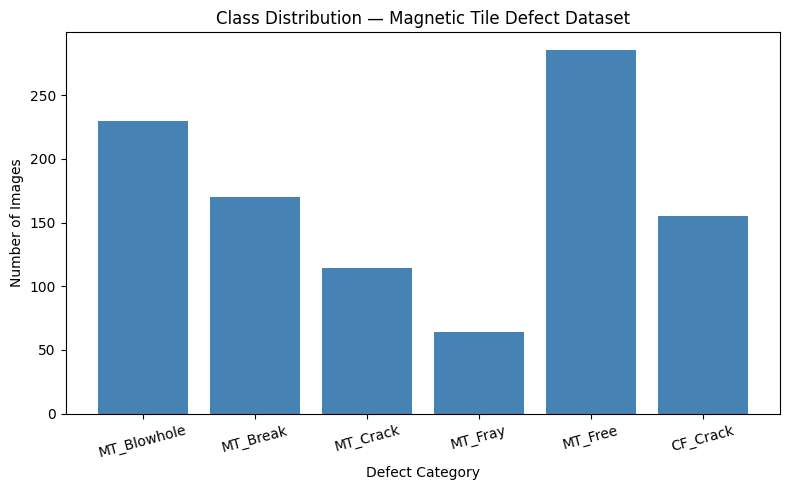

In [11]:
# CELL 6
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.title("Class Distribution — Magnetic Tile Defect Dataset")
plt.xlabel("Defect Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

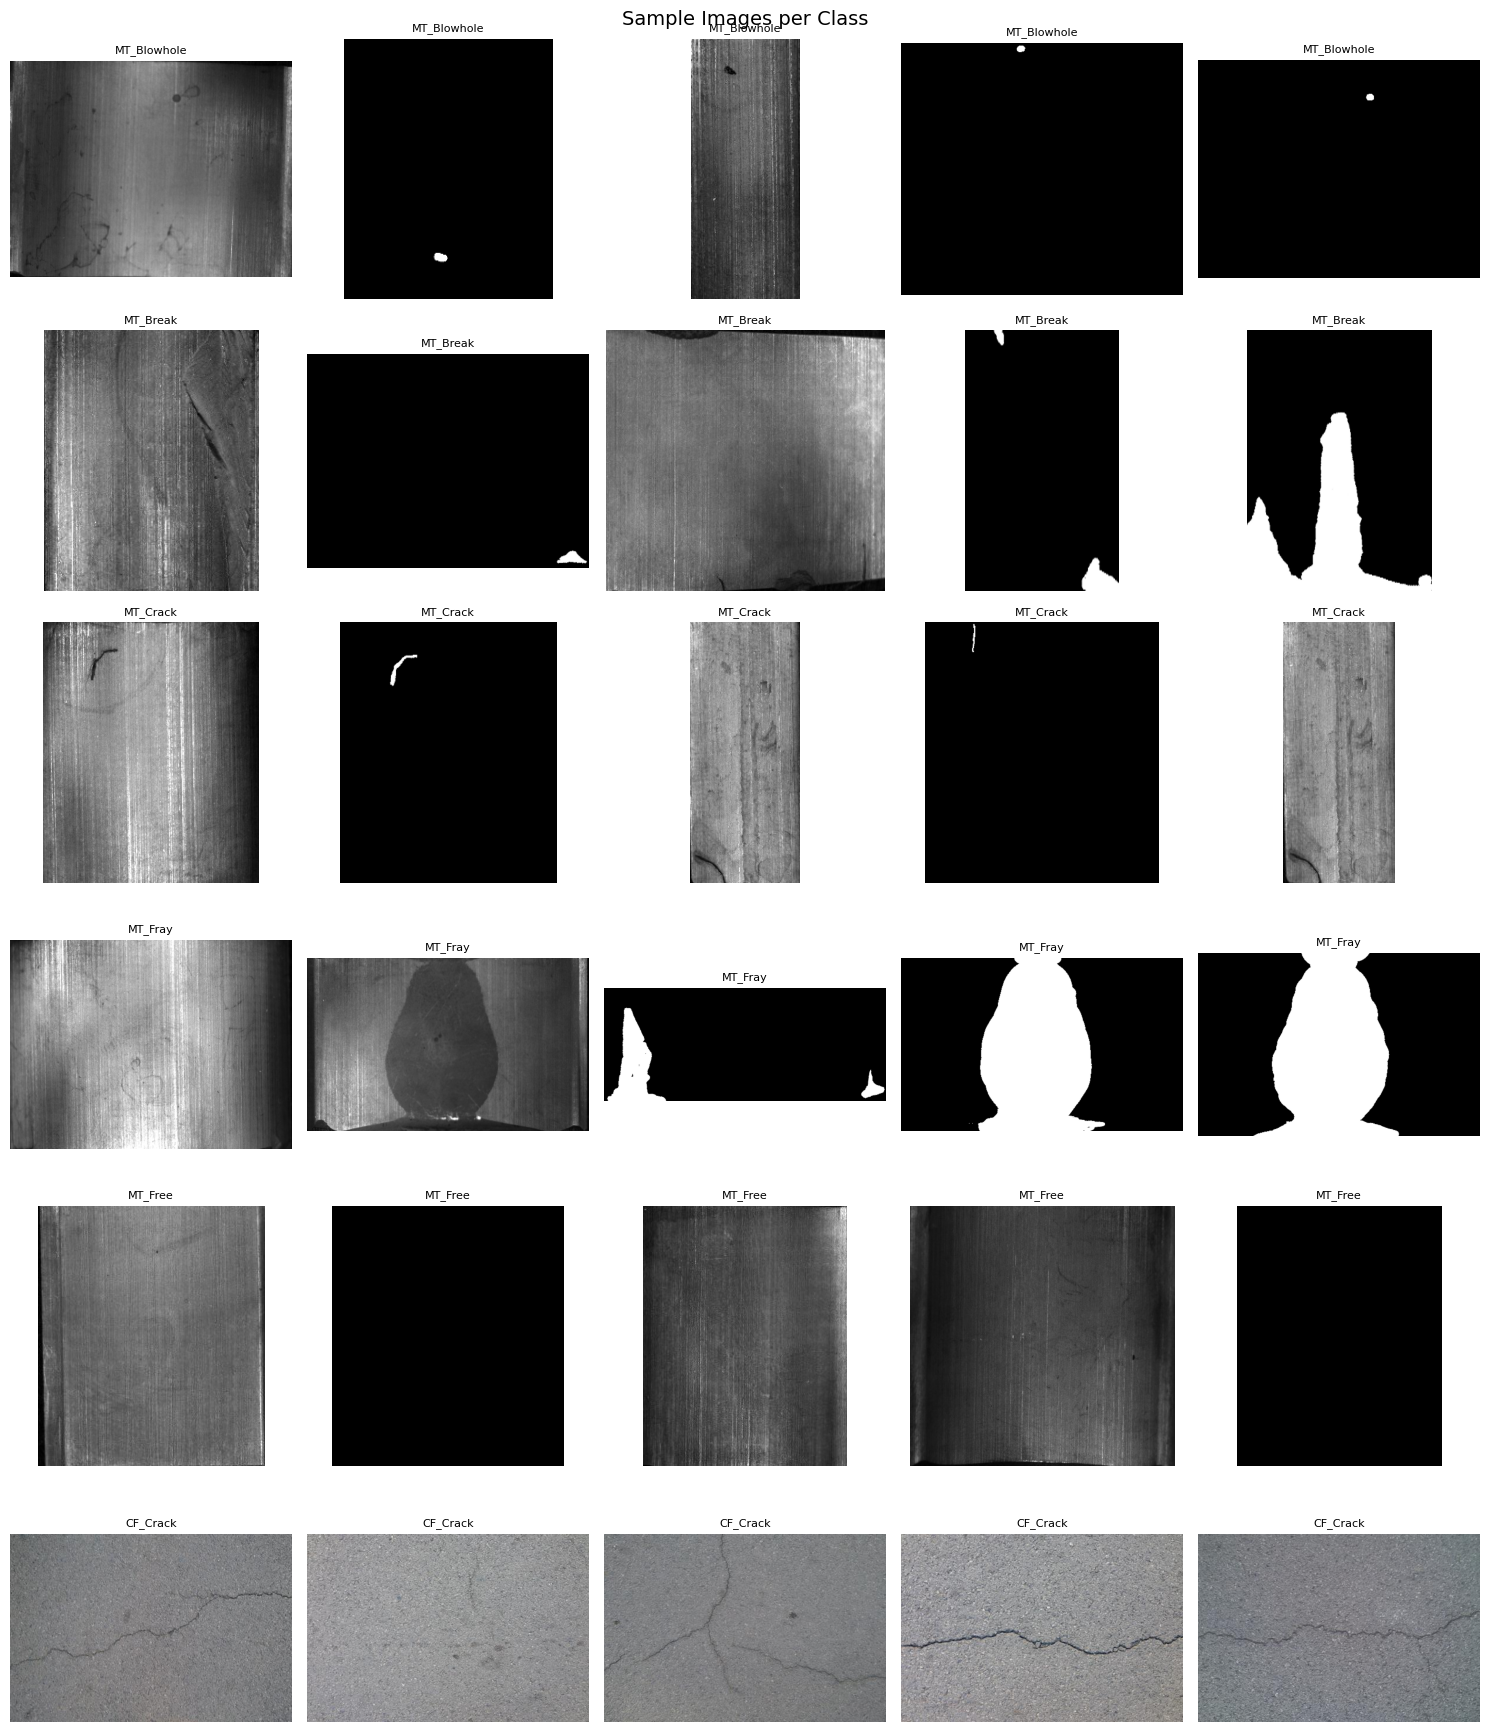

In [15]:
# CELL 7
num_classes = len(class_counts)
fig, axes = plt.subplots(num_classes, 5, figsize=(15, 3 * num_classes))
fig.suptitle("Sample Images per Class", fontsize=14)

for row_idx, cls in enumerate(class_counts.keys()):
    if cls == "CF_Crack":
        cls_path = data_root_cf
    else:
        cls_path = os.path.join(data_root_mt, cls, "Imgs")

    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(valid_extensions)]
    samples = random.sample(all_imgs, min(5, len(all_imgs)))

    for col_idx in range(5):
        ax = axes[row_idx][col_idx]
        if col_idx < len(samples):
            img = mpimg.imread(os.path.join(cls_path, samples[col_idx]))
            ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
            ax.set_title(cls, fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In [16]:
# CELL 8
widths, heights = [], []

for cls in class_counts.keys():
    if cls == "CF_Crack":
        cls_path = data_root_cf
    else:
        cls_path = os.path.join(data_root_mt, cls, "Imgs")
    for f in os.listdir(cls_path):
        if f.lower().endswith(valid_extensions):
            try:
                with Image.open(os.path.join(cls_path, f)) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except:
                pass

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

unique_sizes = Counter(zip(widths, heights))
print(f"\nUnique image sizes: {len(unique_sizes)}")
print("Most common sizes:")
for size, count in unique_sizes.most_common(5):
    print(f"  {size[0]}x{size[1]}: {count} images")

Width  — min: 105, max: 632, mean: 352
Height — min: 227, max: 480, mean: 316

Unique image sizes: 410
Most common sizes:
  480x320: 153 images
  265x375: 6 images
  122x285: 6 images
  596x260: 6 images
  599x244: 6 images


In [17]:
# CELL 9
print("=" * 40)
print("EDA SUMMARY")
print("=" * 40)
print(f"Dataset: Bridge Cracks (Kaggle)")
print(f"Total images: {total_images}")
print(f"Classes: {list(class_counts.keys())}")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} ({count/total_images*100:.1f}%)")
print(f"Planned splits: 70% train / 15% val / 15% test")
print(f"Train: ~{int(total_images*0.70)}, Val: ~{int(total_images*0.15)}, Test: ~{int(total_images*0.15)}")
print(f"Image size (most common): {unique_sizes.most_common(1)[0][0]}")
print("=" * 40)

EDA SUMMARY
Dataset: Bridge Cracks (Kaggle)
Total images: 1018
Classes: ['MT_Blowhole', 'MT_Break', 'MT_Crack', 'MT_Fray', 'MT_Free', 'CF_Crack']
  MT_Blowhole: 230 (22.6%)
  MT_Break: 170 (16.7%)
  MT_Crack: 114 (11.2%)
  MT_Fray: 64 (6.3%)
  MT_Free: 285 (28.0%)
  CF_Crack: 155 (15.2%)
Planned splits: 70% train / 15% val / 15% test
Train: ~712, Val: ~152, Test: ~152
Image size (most common): (480, 320)
